# 0. packages import and matplotlib custom for Overleaf

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.python import tech_colors, ssp_colors

# Set LaTeX style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.2,
    'lines.linewidth': 1.5,
})


# 1. Data extraction

In [2]:
# Load data
td_losses = pd.read_csv("output/operations/TD_losses.csv")
td_weight = pd.read_csv("data/inputs/preprocessed_weights.csv")

# 1. Filter td_losses for 2020s
past_losses = td_losses[td_losses['Decade'] == '2020s'].copy()

# 2. For each SSP, create a copy with ssp = 'past'
# Get unique SSPs in the 2020s data
ssps_in_2020s = td_losses['SSP'].unique()

# Create list to store all past dataframes
past_losses_list = []

for ssp in ssps_in_2020s:
    # Filter for this SSP
    ssp_data = past_losses[past_losses['SSP'] == 'past'].copy()
    
    # Change SSP to 'past'
    ssp_data['SSP'] = ssp
    
    # Append to list
    past_losses_list.append(ssp_data)

# 3. Concatenate all past data and add to original td_losses
if past_losses_list:
    all_past_losses = pd.concat(past_losses_list, ignore_index=True)
    td_losses = pd.concat([td_losses, all_past_losses], ignore_index=True)
else:
    print("Warning: No 2020s data found in td_losses")

td_losses

,SSP,Decade,Day,Hour,Loss_type,Value
0,past,2020s,12,0,Wall,-423.519948
1,past,2020s,12,0,Ventilation,-16.940798
2,past,2020s,12,0,Solar,0.015272
3,past,2020s,12,0,Internal,105.000000
4,past,2020s,12,1,Wall,-440.559561
...,...,...,...,...,...,...
52219,ssp585,2020s,1,22,Internal,105.000000
52220,ssp585,2020s,1,23,Wall,-1067.509945
52221,ssp585,2020s,1,23,Ventilation,-42.700398
52222,ssp585,2020s,1,23,Solar,0.001163


# 2. Plotting
## 2.1. plotting gains and losses per category

Processing data...

Creating Gains plot...


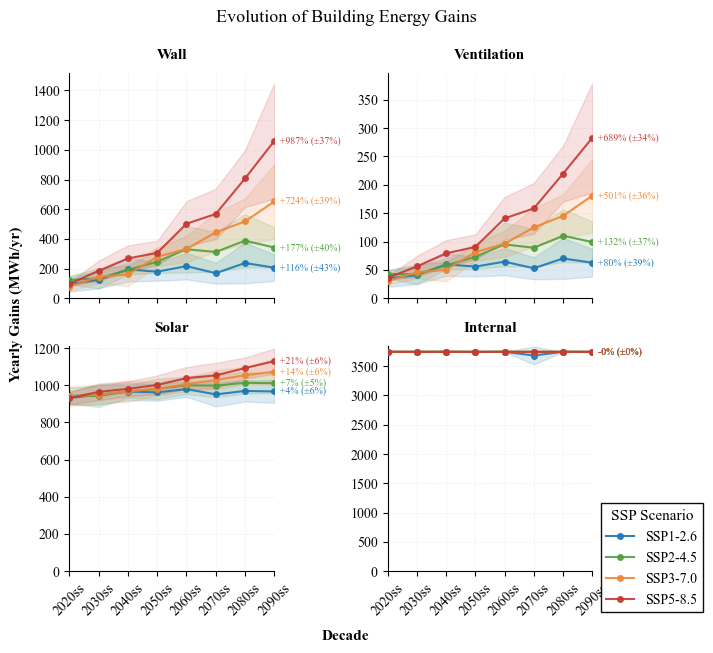


Creating Losses plot...


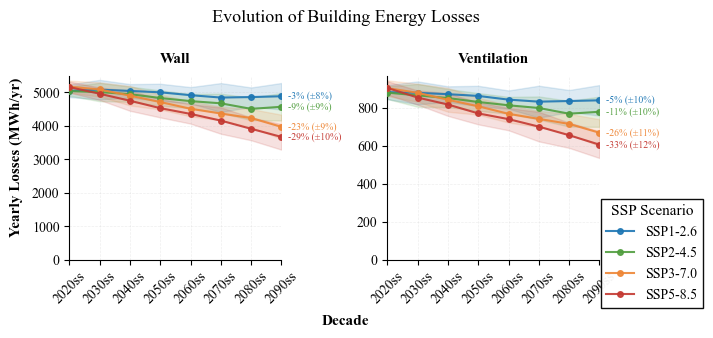


SUMMARY TABLES

Gains (MWh/yr):
ssp_formatted       SSP1-2.6  SSP2-4.5  SSP3-7.0  SSP5-8.5
Loss_type   decade                                        
Internal    2020s     3746.2    3746.2    3746.2    3746.2
            2030s     3745.1    3745.1    3745.1    3745.1
            2040s     3746.2    3746.2    3746.2    3746.2
            2050s     3745.1    3745.1    3745.1    3745.1
            2060s     3746.2    3746.2    3746.2    3746.2
            2070s     3682.7    3745.1    3745.1    3745.1
            2080s     3746.2    3746.2    3746.2    3746.2
            2090s     3745.1    3745.1    3745.1    3745.1
Solar       2020s      931.5     943.4     940.0     930.9
            2030s      948.8     942.5     948.7     964.4
            2040s      966.2     966.7     967.8     980.8
            2050s      961.8     980.1     980.3    1001.9
            2060s      979.5     999.8    1005.1    1038.1
            2070s      950.7     997.9    1028.3    1053.0
            2080s      

In [4]:
# Prepare the data
td_sum = td_losses.groupby(['SSP', 'Decade', 'Day', 'Loss_type'])['Value'].sum().reset_index().rename(columns={'Value':'value'})
td_sum = td_sum.rename(columns={'SSP': 'ssp', 'Decade': 'decade', 'Day': 'td'})

# Separate gains (positive) and losses (negative)
td_sum_gains = td_sum[td_sum['value'] > 0].copy()
td_sum_losses = td_sum[td_sum['value'] < 0].copy()
td_sum_losses['value'] = -td_sum_losses['value']  # Make losses positive

# Prepare weights
td_weight_sum = td_weight.groupby(['gcm', 'ssp', 'decade', 'td']).sum().reset_index()

def format_ssp_name(ssp):
    """Format SSP names as SSPX-X.X"""
    if ssp == 'past':
        return 'Historical'
    elif ssp.startswith('ssp'):
        num = ssp[3:]
        if len(num) == 3:
            return f'SSP{num[0]}-{num[1]}.{num[2]}'
    return ssp

def process_data(data_df):
    """Process data and return statistics."""
    merged = pd.merge(data_df, td_weight_sum, on=['ssp', 'decade', 'td'], how='left')
    merged['weighted_value'] = merged['value'] * merged['weight'] / 1000 / 10
    
    # Handle missing values with past data
    past_values = merged[merged['ssp'] == 'past'].copy()
    for _, row in past_values.iterrows():
        mask = (merged['decade'] == row['decade']) & (merged['td'] == row['td']) & (merged['Loss_type'] == row['Loss_type'])
        merged.loc[mask & merged['weighted_value'].isna(), 'weighted_value'] = row['weighted_value']
    
    # Calculate statistics across GCMs
    gcm_stats = merged.groupby(['ssp', 'decade', 'Loss_type', 'gcm'])['weighted_value'].sum().reset_index()
    stats = gcm_stats.groupby(['ssp', 'decade', 'Loss_type']).agg(
        mean_value=('weighted_value', 'mean'),
        std_value=('weighted_value', 'std'),
        count=('weighted_value', 'size')
    ).reset_index()
    
    # Format SSP names
    stats['ssp_formatted'] = stats['ssp'].apply(format_ssp_name)
    
    return stats

def create_comparison_annotation(ax, stats, loss_type, recent_decade='2090s', ref_decade='2020s', color = 'black'):
    """Add annotation showing evolution from reference decade."""
    # Get data for the specified decades
    recent_data = stats[(stats['decade'] == recent_decade) & (stats['Loss_type'] == loss_type)]
    ref_data = stats[(stats['decade'] == ref_decade) & (stats['Loss_type'] == loss_type)]

    if len(recent_data) == 0 or len(ref_data) == 0:
        return
    
    # Get the tick positions and labels
    xticks = ax.get_xticks()
    xticklabels = ax.get_xticklabels()
    
    # Create a mapping from label to position
    tick_dict = {label.get_text(): pos for label, pos in zip(xticklabels, xticks)}
    
    # Get x-position for the recent decade
    if recent_decade in tick_dict:
        x_pos = tick_dict[recent_decade]
    else:
        # Fallback if not found
        x_pos = xticks[-1]  # Last tick
    
    # Calculate relative changes for each SSP
    for ssp in recent_data['ssp'].unique():
        recent_row = recent_data[recent_data['ssp'] == ssp].iloc[0]
        ref_row = ref_data[ref_data['ssp'] == ssp].iloc[0] if ssp in ref_data['ssp'].values else None
        
        if ref_row is not None and recent_row['mean_value'] != 0:
            rel_change = ((recent_row['mean_value'] - ref_row['mean_value']) / 
                         abs(ref_row['mean_value']) * 100)
            std_ratio = recent_row['std_value'] / recent_row['mean_value'] * 100 if recent_row['mean_value'] != 0 else 0
            
            # Format the annotation
            ssp_name = format_ssp_name(ssp)
            annotation = f"{rel_change:+.0f}% (±{std_ratio:.0f}%)"
            
            # Position relative to tick (using data coordinates)
            annotation_x = x_pos + 0.2  # 1 unit to the right of the tick
            
            # Add text annotation
            ax.text(annotation_x, recent_row['mean_value'], annotation,
                   fontsize=7, verticalalignment='center', color = color[ssp_name],
                #    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                #             alpha=0.85, edgecolor='lightgray', linewidth=0.5)
                            )

def create_plot(stats, title_suffix, plot_type="Gains"):
    """Create LaTeX-style plot with bands."""
    loss_types = np.flip(stats['Loss_type'].unique())
    n_loss_types = len(loss_types)
    n_cols = 2
    n_rows = (n_loss_types + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 3.5 * n_rows), 
                            sharex=True, sharey=False)
    axes = axes.flatten() if n_loss_types > 1 else [axes]
    
    # Color palette
    
    ssp_order = ['Historical', 'SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
    
    # Plot each loss type
    for idx, loss_type in enumerate(loss_types):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        loss_data = stats[stats['Loss_type'] == loss_type]
        decades = sorted(loss_data['decade'].unique())
        
        for ssp_name in ssp_order:
            ssp_data = loss_data[loss_data['ssp_formatted'] == ssp_name]
            if len(ssp_data) > 0:
                ssp_sorted = ssp_data.sort_values('decade')
                x_vals = ssp_sorted['decade']
                y_vals = ssp_sorted['mean_value']
                y_err = ssp_sorted['std_value']
                
                # Plot line with fill_between for uncertainty bands
                line = ax.plot(x_vals, y_vals, marker='o', markersize=4,
                             color=ssp_colors[ssp_name], 
                             label=ssp_name if idx == 0 else "",  # Add to legend only once
                             alpha=0.9, zorder=5)
                
                # Add uncertainty band
                ax.fill_between(x_vals, y_vals - y_err, y_vals + y_err,
                               color=ssp_colors[ssp_name], alpha=0.15, zorder=1)
        
        # Customize subplot
        ax.set_title(f'{loss_type}', fontsize=11, pad=10)
        ax.set_xlabel('')
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        ax.set_xticks(decades)
        ax.set_xticklabels([f'{d}s' for d in decades], rotation=45)
        ax.set_ylim(0)
        # Set xlim using tick indices (0, 1, 2, ...)
        ax.set_xlim(0, len(x_vals) - 1)
        # Remove the top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Optional: Keep only left and bottom spines
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        # Add annotation for 2090s
        if '2090s' in decades:
            create_comparison_annotation(ax, stats, loss_type, color = ssp_colors)
    
    # Set common labels
    fig.text(0.5, 0.02, 'Decade', ha='center', fontsize=11, fontweight='bold')
    fig.text(0.02, 0.5, f'Yearly {plot_type} (MWh/yr)', va='center', 
             rotation='vertical', fontsize=11, fontweight='bold')

    # Add single legend on the right with proper spacing
    handles_labels = axes[0].get_legend_handles_labels()
    if handles_labels[0]:
        legend = fig.legend(handles_labels[0], handles_labels[1],
                          loc='lower right', bbox_to_anchor=(1.02, 0.05),
                          ncol=1, fontsize=10, frameon=True, framealpha=0.95,
                          edgecolor='black', fancybox=False, 
                          title='SSP Scenario')
        legend.get_title().set_fontsize(11)
    
    # Adjust layout
    plt.suptitle(f'Evolution of Building Energy {plot_type}', 
                 fontsize=13, y=0.92)
    plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.93])
    
    return fig

# Process data
print("Processing data...")
gains_stats = process_data(td_sum_gains)
losses_stats = process_data(td_sum_losses)

# Create plots
print("\nCreating Gains plot...")
fig_gains = create_plot(gains_stats, "gains", "Gains")
plt.savefig('output/operations/energy_gains_evolution.pdf', dpi=300, bbox_inches='tight')
plt.savefig('output/operations/energy_gains_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCreating Losses plot...")
fig_losses = create_plot(losses_stats, "losses", "Losses")
plt.savefig('output/operations/energy_losses_evolution.pdf', dpi=300, bbox_inches='tight')
plt.savefig('output/operations/energy_losses_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary tables
print("\n" + "="*60)
print("SUMMARY TABLES")
print("="*60)

for stats, name in [(gains_stats, "Gains"), (losses_stats, "Losses")]:
    print(f"\n{name} (MWh/yr):")
    summary = stats.pivot_table(
        index=['Loss_type', 'decade'],
        columns='ssp_formatted',
        values='mean_value',
        aggfunc='mean'
    ).round(1)
    print(summary)

## 2.2. Plotting the net balance

Computing total balance per day...
        ssp decade  td         value
16   ssp126  2020s   0 -53136.558212
17   ssp126  2020s   1 -18973.346455
18   ssp126  2020s   2 -12613.053990
19   ssp126  2020s   3  -7917.726352
20   ssp126  2020s   4  -3978.917915
..      ...    ...  ..           ...
523  ssp585  2090s  11   3366.262840
524  ssp585  2090s  12   4096.509073
525  ssp585  2090s  13   9942.310984
526  ssp585  2090s  14  16224.639603
527  ssp585  2090s  15  64918.106273

[512 rows x 4 columns]
Positive balance days: 160
Negative balance days: 352
Total days: 512

Processing total gains (positive balance)...

Processing total losses (negative balance, made positive)...

Creating combined Net Gains & Net Losses plot...
Empty DataFrame
Columns: [ssp, decade, Loss_type, mean_value, std_value, count, ssp_formatted]
Index: []
      ssp decade Loss_type  mean_value   std_value  count ssp_formatted
0  ssp126  2020s     Total  690.128230  146.823606      6      SSP1-2.6
7  ssp126  2090s    

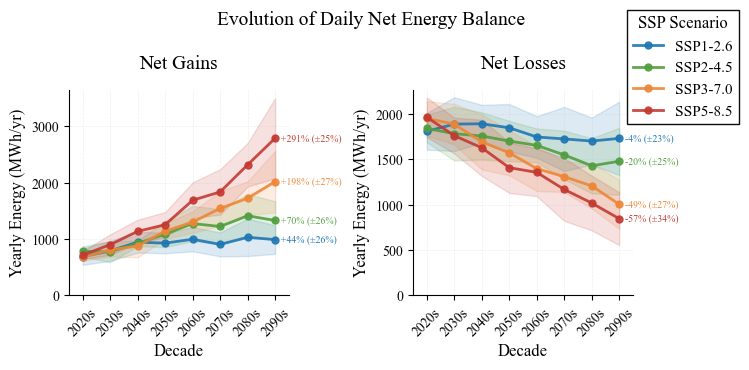

In [5]:


# Compute total balance per day (sum across all loss types)
print("Computing total balance per day...")
td_balance = td_losses.groupby(['SSP', 'Decade', 'Day'])['Value'].sum().reset_index()
td_balance = td_balance[td_balance['SSP'] != 'past']
td_balance = td_balance.rename(columns={'SSP': 'ssp', 'Decade': 'decade', 'Day': 'td', 'Value': 'value'})
print(td_balance)
# Add 'Loss_type' column with value 'Total' for all rows
td_balance['Loss_type'] = 'Total'

# Separate positive (net gains) and negative (net losses) balances
td_balance_gains = td_balance[td_balance['value'] > 0].copy()
td_balance_losses = td_balance[td_balance['value'] < 0].copy()

# Make losses positive for plotting (absolute values)
td_balance_losses['value'] = -td_balance_losses['value']

print(f"Positive balance days: {len(td_balance_gains)}")
print(f"Negative balance days: {len(td_balance_losses)}")
print(f"Total days: {len(td_balance)}")

# Process the data using existing function
print("\nProcessing total gains (positive balance)...")
total_gains_stats = process_data(td_balance_gains)

print("\nProcessing total losses (negative balance, made positive)...")
total_losses_stats = process_data(td_balance_losses)


def create_combined_total_plot(total_gains_stats, total_losses_stats, save_name="total_balance_combined"):
    """
    Create a combined figure with two subplots:
    - Left: Net Gains
    - Right: Net Losses
    """
    # Create figure with 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=False)
    
    ssp_order = ['Historical', 'SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
    
    # Prepare data for both subplots
    plots_data = [
        (axes[0], total_gains_stats, "Net Gains"),
        (axes[1], total_losses_stats, "Net Losses")
    ]
    
    for ax, stats, plot_title in plots_data:
        # Filter for 'Total' loss type
        total_stats = stats[stats['Loss_type'] == 'Total']
        if len(total_stats) == 0:
            continue
            
        decades = sorted(total_stats['decade'].unique())
        
        # Create numerical mapping for decades
        decade_to_num = {decade: i for i, decade in enumerate(decades)}
        
        for ssp_name in ssp_order:
            ssp_data = total_stats[total_stats['ssp_formatted'] == ssp_name]
            print(ssp_data[(ssp_data['decade'] == '2090s') | (ssp_data['decade'] == '2020s')])
            if len(ssp_data) > 0:
                ssp_sorted = ssp_data.sort_values('decade')
                x_labels = ssp_sorted['decade']
                x_numerical = [decade_to_num[d] for d in x_labels]
                y_vals = ssp_sorted['mean_value']
                y_err = ssp_sorted['std_value']
                
                # Plot line with fill_between for uncertainty bands
                line = ax.plot(x_numerical, y_vals, marker='o', markersize=5,
                             color=ssp_colors[ssp_name], 
                             label=ssp_name if ax == axes[0] else "",  # Add to legend only once
                             alpha=0.9, zorder=5, linewidth=2)
                
                # Add uncertainty band
                ax.fill_between(x_numerical, y_vals - y_err, y_vals + y_err,
                               color=ssp_colors[ssp_name], alpha=0.15, zorder=1)
        
        # Set x-axis ticks and limits
        ax.set_xticks(range(len(decades)))
        ax.set_xticklabels(decades, rotation=45)
        ax.set_xlim(-0.5, len(decades) - 0.5)
        
        # Customize subplot
        ax.set_title(f'{plot_title}', fontsize=14, pad=15, fontweight='normal')
        ax.set_xlabel('Decade', fontsize=12)
        ax.set_ylabel('Yearly Energy (MWh/yr)', fontsize=12)
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        ax.set_ylim(0)
        
        # Remove the top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        
        # Add annotation for 2090s
        if '2090s' in decades:
            create_comparison_annotation(ax, stats, 'Total', color=ssp_colors)
    
    # Add single legend for both subplots (on the right side)
    handles_labels = axes[0].get_legend_handles_labels()
    if handles_labels[0]:
        legend = fig.legend(handles_labels[0], handles_labels[1],
                          loc='center right', bbox_to_anchor=(0.97, 0.8),
                          ncol=1, fontsize=11, frameon=True, framealpha=0.95,
                          edgecolor='black', fancybox=False, 
                          title='SSP Scenario')
        legend.get_title().set_fontsize(12)
    
    # Adjust layout
    plt.suptitle('Evolution of Daily Net Energy Balance', 
                 fontsize=14, fontweight='normal', y=0.94)
    plt.tight_layout(rect=[0.03, 0.03, 0.90, 0.95])
    
    # Save figure
    plt.savefig(f'output/operations/{save_name}.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'output/operations/{save_name}.png', dpi=300, bbox_inches='tight')
    
    return fig

# Create combined plot
print("\nCreating combined Net Gains & Net Losses plot...")
fig_combined = create_combined_total_plot(total_gains_stats, total_losses_stats, "total_net_balance_combined")

plt.savefig('output/operations/losses.png', dpi = 600, bbox_inches='tight')

## 2.3. Plotting by typical day the heat gains and losses
### Daily average

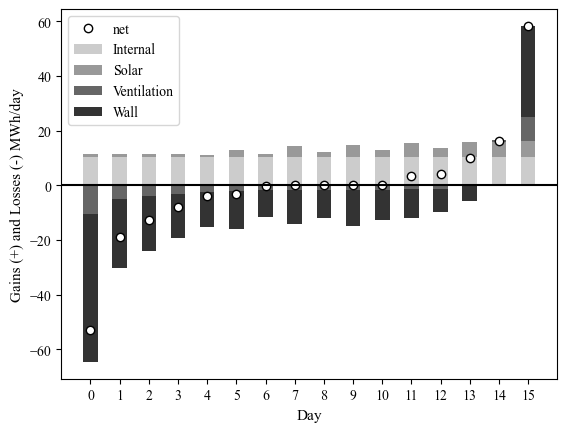

In [6]:
# SSP	Decade	Day	Hour	Loss_type	Value
# Extract unique loss types from the data

mask = (td_losses['SSP'] == 'ssp126') * (td_losses['Decade'] == '2020s')
loss_types = td_losses[mask]['Loss_type'].unique()
n_types = len(loss_types)
grey_shades = np.linspace(0.2, 0.8, n_types)  # Range from dark to light grey
loss_type_colors = {loss_type: str(shade) for loss_type, shade in zip(loss_types, grey_shades)}
pivot_data = td_losses[mask].pivot_table(index='Day', columns='Loss_type', values='Value', aggfunc='sum') /1000
pivot_data.plot(kind='bar', stacked=True, color=[loss_type_colors[col] for col in pivot_data.columns])
pivot_data.sum(axis=1).plot(marker='o', linestyle='', color='white', markeredgecolor = 'black', label = 'net')
plt.hlines(xmin=td_losses['Day'].min()-1, xmax=td_losses['Day'].max()+1, y=0, color='k')
plt.xlim(td_losses['Day'].min()-1, td_losses['Day'].max()+1)
plt.ylabel('Gains (+) and Losses (-) MWh/day')
plt.legend()

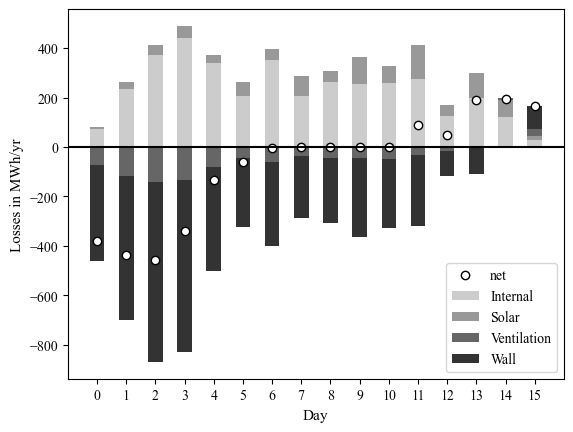

In [7]:
processed_weight = td_weight[['ssp','decade','td','weight']].groupby(['ssp','decade','td']).mean().reset_index().rename(columns={'ssp':'SSP', 'decade':'Decade','td':'Day'})
joined_df = td_losses.merge(processed_weight, on=['SSP', 'Decade', 'Day'])
joined_df['Value'] = joined_df['Value'] * joined_df['weight'] / 10 / 1e3 # / 10 years / 1000 kWh -> MWh


mask = (joined_df['SSP'] == 'ssp126') * (joined_df['Decade'] == '2020s')
loss_types = joined_df[mask]['Loss_type'].unique()
n_types = len(loss_types)
grey_shades = np.linspace(0.2, 0.8, n_types)  # Range from dark to light grey
loss_type_colors = {loss_type: str(shade) for loss_type, shade in zip(loss_types, grey_shades)}
pivot_data = joined_df[mask].pivot_table(index='Day', columns='Loss_type', values='Value', aggfunc='sum')
pivot_data.plot(kind='bar', stacked=True, color=[loss_type_colors[col] for col in pivot_data.columns])
pivot_data.sum(axis=1).plot(marker='o', linestyle='', color='white', markeredgecolor = 'black', label = 'net')
plt.hlines(xmin=joined_df['Day'].min()-1, xmax=joined_df['Day'].max()+1, y=0, color='k')
plt.xlim(joined_df['Day'].min()-1, joined_df['Day'].max()+1)
plt.ylabel('Losses in MWh/yr')
plt.legend()